In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

print("Training Shape:", x_train.shape)
print("Testing Shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 15s 0us/step
Training Shape: (50000, 32, 32, 3)
Testing Shape: (10000, 32, 32, 3)


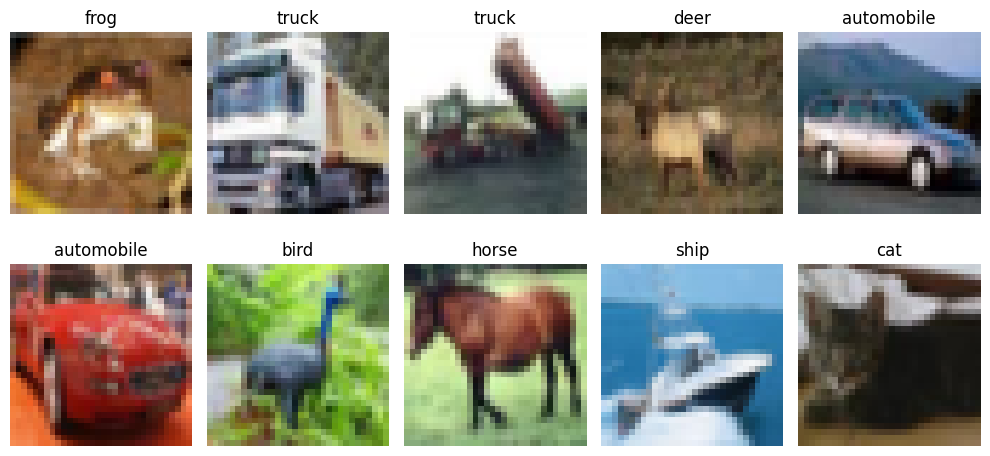

In [ ]:
class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

print("Flattened Shape:", x_train_flat.shape)

Flattened Shape: (50000, 3072)


In [ ]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),

    layers.Dense(256, activation='relu'),

    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
ann_history = ann_model.fit(
    x_train_flat,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 27ms/step - accuracy: 0.2659 - loss: 2.0068 - val_accuracy: 0.3408 - val_loss: 1.8415
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.3092 - loss: 1.8790 - val_accuracy: 0.3710 - val_loss: 1.7663
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 26ms/step - accuracy: 0.3299 - loss: 1.8205 - val_accuracy: 0.3802 - val_loss: 1.7558
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.3409 - loss: 1.8019 - val_accuracy: 0.3944 - val_loss: 1.7235
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 26ms/step - accuracy: 0.3509 - loss: 1.7788 - val_accuracy: 0.3974 - val_loss: 1.7258
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.3630 - loss: 1.7547 - val_accuracy: 0.4002 - val_loss: 1.7142
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.3648 - loss: 1.7400 - val_accuracy: 0.4030 - val_loss: 1.7085
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 26ms/step - accuracy: 0.3695 - loss: 1.7301 - 

In [ ]:
ann_loss, ann_acc = ann_model.evaluate(
    x_test_flat,
    y_test
)

print("ANN Test Accuracy:", ann_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4309 - loss: 1.6508
ANN Test Accuracy: 0.4309000074863434


In [ ]:
cnn_model = models.Sequential([

    layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(32,32,3)
    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D((2,2)),

    layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(
        128,
        activation='relu'
    ),

    layers.Dense(
        10,
        activation='softmax'
    )
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 316,106 (1.21 MB)

 Trainable params: 315,914 (1.21 MB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
cnn_history = cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 75s 104ms/step - accuracy: 0.5377 - loss: 1.3185 - val_accuracy: 0.6248 - val_loss: 1.1037
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 71s 101ms/step - accuracy: 0.6756 - loss: 0.9297 - val_accuracy: 0.6480 - val_loss: 1.0165
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 71s 101ms/step - accuracy: 0.7374 - loss: 0.7504 - val_accuracy: 0.6458 - val_loss: 1.0468
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 100ms/step - accuracy: 0.7866 - loss: 0.6083 - val_accuracy: 0.7024 - val_loss: 0.9079
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 72s 102ms/step - accuracy: 0.8274 - loss: 0.4893 - val_accuracy: 0.7084 - val_loss: 0.9796
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 101ms/step - accuracy: 0.8710 - loss: 0.3683 - val_accuracy: 0.6770 - val_loss: 1.2425
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 71s 100ms/step - accuracy: 0.9029 - loss: 0.2768 - val_accuracy: 0.6914 - val_loss: 1.1674
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 101ms/step - accuracy: 0.9251 - loss: 0

In [ ]:
cnn_loss, cnn_acc = cnn_model.evaluate(
    x_test_norm,
    y_test
)

print("CNN Test Accuracy:", cnn_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.6539 - loss: 1.7073
CNN Test Accuracy: 0.6539000272750854


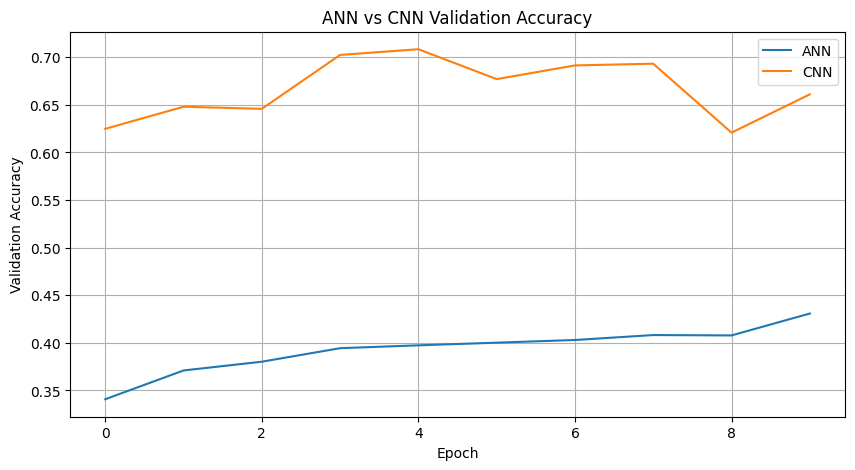

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(
    ann_history.history['val_accuracy'],
    label='ANN'
)

plt.plot(
    cnn_history.history['val_accuracy'],
    label='CNN'
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

In [ ]:
aug_cnn_model = models.Sequential([

    data_augmentation,

    layers.Conv2D(
        32,
        3,
        activation='relu',
        input_shape=(32,32,3)
    ),

    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(
        64,
        3,
        activation='relu'
    ),

    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(
        128,
        3,
        activation='relu'
    ),

    layers.Flatten(),

    layers.Dense(
        128,
        activation='relu'
    ),

    layers.Dropout(0.4),

    layers.Dense(
        10,
        activation='softmax'
    )
])

aug_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

aug_cnn_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
aug_history = aug_cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop]
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 95s 128ms/step - accuracy: 0.4016 - loss: 1.6633 - val_accuracy: 0.5230 - val_loss: 1.3207
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 126ms/step - accuracy: 0.5045 - loss: 1.4003 - val_accuracy: 0.5338 - val_loss: 1.3230
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 90s 127ms/step - accuracy: 0.5489 - loss: 1.2772 - val_accuracy: 0.5538 - val_loss: 1.2452
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 90s 128ms/step - accuracy: 0.5814 - loss: 1.2022 - val_accuracy: 0.5602 - val_loss: 1.3226
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 127ms/step - accuracy: 0.6010 - loss: 1.1434 - val_accuracy: 0.5984 - val_loss: 1.1329
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 90s 127ms/step - accuracy: 0.6215 - loss: 1.0941 - val_accuracy: 0.6582 - val_loss: 0.9533
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 126ms/step - accuracy: 0.6334 - loss: 1.0549 - val_accuracy: 0.6424 - val_loss: 1.0180
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 91s 129ms/step - accuracy: 0.6501 - loss

In [ ]:
aug_loss, aug_acc = aug_cnn_model.evaluate(
    x_test_norm,
    y_test
)

print("Augmented CNN Accuracy:", aug_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.6864 - loss: 0.9210
Augmented CNN Accuracy: 0.6863999962806702


In [ ]:
cnn_loss, cnn_acc = cnn_model.evaluate(
    x_test_norm,
    y_test
)

print("CNN Test Accuracy (re-evaluated):", cnn_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.6539 - loss: 1.7073
CNN Test Accuracy (re-evaluated): 0.6539000272750854


In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "ANN",
        "CNN",
        "Augmented CNN"
    ],
    "Test Accuracy": [
        ann_acc,
        cnn_acc,
        aug_acc
    ]
})

comparison

,Model,Test Accuracy
0,ANN,0.4309
1,CNN,0.6539
2,Augmented CNN,0.6864
